# # Background — Probability for Classification (อ่านก่อนเข้าโมดูล classification)
#
# โน้ตบุ๊กนี้รวบความรู้ความน่าจะเป็นที่โมดูล classification จะใช้ — เจาะจงในมุมงานวัด: ความน่าจะเป็นคืออะไร, เงื่อนไข P(pass | measurement), ทฤษฎี Bayes, กับดัก base rate, Bernoulli/Binomial ของผล pass/fail, สมมติฐาน Gaussian ต่อ feature — และศัพท์เมโทรโลยีสำคัญ: **false accept** (รับของเสียผ่าน) กับ **false reject** (ตัดของดีทิ้ง)
#
# ตัวเลขที่ใช้ร้อยเรื่องตลอดโน้ตบุ๊ก: อัตรา fail ~6.6% ของงานผลิต (มาจาก dataset SECOM ที่จะใช้จริงในโมดูลหลัก — 1,04 ใน 1,567 ชิ้น)

# ## 1. ความน่าจะเป็น — การวัดความเชื่อและความถี่
#
# ความน่าจะเป็นมีสองมุมอ่าน ทั้งสองมุมให้ตัวเลขเดียวกัน:
#
# - **ความถี่ (frequency):** ทำซ้ำอีกนับพันครั้ง สัดส่วนที่เหตุการณ์เกิดขึ้น — เช่น ผลิตชิ้นงาน 10,000 ชิ้น ได้ fail 660 ชิ้น → P(fail) = 0.066
# - **ความเชื่อ (belief):** ระดับความเชื่อมั่นในหน่วย 0–1 ว่า "ชิ้นงานชิ้นนี้ (ที่ยังไม่วัด) เป็นของเสีย" — ตัวเลขเดียวกัน 0.066 แต่ตีความเป็นความเชื่อก่อนเห็นผล
#
# กฎพื้นฐานที่จะใช้ตลอด: ความน่าจะเป็นอยู่ในช่วง [0, 1] และความน่าจะเป็นของทุกทางเลือกรวมกัน = 1 → P(pass) + P(fail) = 1

ฟอนต์ไทยสำหรับป้ายกราฟ — fallback list รองรับทุกแพลตฟอร์ม (macOS/Windows)

จำลองสายการผลิต 10,000 ชิ้น โดย P(fail) = 0.066 (base rate ของ SECOM)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = [
    "DejaVu Sans",
    "Noto Sans Thai",
    "Leelawadee UI",
    "Tahoma",
    "Thonburi",
]

rng = np.random.default_rng(42)

n_units = 10_000
p_fail = 0.066
outcomes = rng.random(n_units) < p_fail  # True = fail

freq_fail = outcomes.mean()
print(
    f"simulate {n_units:,} ชิ้น → fail {outcomes.sum()} ชิ้น, ความถี่ = {
        freq_fail:.4f} (จริง 0.066)"
)
print(f"P(pass) = {1 - freq_fail:.4f} — สองทางรวมกัน = 1 เสมอ")

simulate 10,000 ชิ้น → fail 673 ชิ้น, ความถี่ = 0.0673 (จริง 0.066)
P(pass) = 0.9327 — สองทางรวมกัน = 1 เสมอ


# สังเกต: ความถี่ที่ได้ (~0.065) ใกล้ 0.066 แต่ไม่เท่าเป๊ะ — **sampling error** ที่เรียนมาใน background ของ Module 3 ยังอยู่กับเรา ยิ่งจำนวนชิ้นมาก ความถี่ยิ่งเข้าใกล้ความน่าจะเป็นจริง

# ## 2. Conditional probability — P(pass | measurement)
#
# ความน่าจะเป็นแบบมีเงื่อนไขคือหัวใจของ classifier:
#
# ```text
# P(fail | measurement) = โอกาสที่ชิ้นงาน fail โดย "รู้ค่าที่วัดได้แล้ว"
# ```
#
# ก่อนวัด: เรารู้แค่ P(fail) = 0.066 (base rate)
# หลังวัด: ค่าที่วัดได้ปรับความเชื่อของเราขึ้นหรือลง
#
# ทางคำนวณง่ายที่สุดคือ **นับความถี่ในกลุ่มย่อย** — แบ่งชิ้นงานตามค่าที่วัด แล้วดูอัตรา fail ในแต่ละช่วง

จำลอง: probe วัดหนึ่งค่า ชิ้น pass มักอ่านได้ราว 10.00, ชิ้น fail มักเบี่ยงไปราว 10.45

นับอัตรา fail ตามช่วงค่าที่วัดได้ (conditional probability จากความถี่จริง)


In [2]:
n = 20_000
is_fail = rng.random(n) < p_fail
reading = np.where(
    is_fail, rng.normal(10.45, 0.15, n), rng.normal(10.00, 0.15, n)
)

print(
    f"{'ช่วงค่าที่วัด':>18s} | {'จำนวนชิ้น':>9s} | "
    f"{'อัตรา fail ในช่วง':>16s}"
)
for lo, hi in [
    (9.5, 9.9),
    (9.9, 10.1),
    (10.1, 10.3),
    (10.3, 10.5),
    (10.5, 11.0),
]:
    band = (reading >= lo) & (reading < hi)
    if band.sum() > 0:
        rate = is_fail[band].mean()
        print(
            f"{f'[{lo:.1f}, {hi:.1f})':>18s} | {int(band.sum()):9d} | {
                rate:16.3f}"
        )

     ช่วงค่าที่วัด | จำนวนชิ้น | อัตรา fail ในช่วง
        [9.5, 9.9) |      4708 |            0.000
       [9.9, 10.1) |      9275 |            0.002
      [10.1, 10.3) |      4468 |            0.043
      [10.3, 10.5) |      1080 |            0.598
      [10.5, 11.0) |       460 |            0.976


# อ่านตาราง: ชิ้นที่อ่านได้ต่ำ (10.0 ลงมา) fail แทบไม่มี — ชิ้นที่อ่านสูง 10.5 ขึ้นไป fail เกือบทั้งหมด
# นี่คือสาระของ **P(fail | measurement)**: ค่าที่วัดเปลี่ยนความเชื่อเราจาก 0.066 ไปเกือบ 0 หรือเกือบ 1
#
# ประโยคนี้คือนิยามของ classifier ทั้งหมด: **classifier = เครื่องประมาณ P(fail | measurement)** โดยวัดหลายค่าพร้อมกัน

# ## 3. Bayes' theorem — คำนวณจากตัวเลขจริง
#
# เราอยากได้ P(fail | gauge เตือน) — "เครื่องตรวจเตือนว่าเสีย แล้วจริงไหม" — แต่สิ่งที่ผู้ผลิต gauge บอกเรามักเป็นทิศตรงข้าม:
#
# - **sensitivity** = P(เตือน | fail) — จับของเสียได้ดีแค่ไหน
# - **false positive rate** = P(เตือน | pass) — ตัดสินผิดกับของดีบ่อยแค่ไหน
#
# ทฤษฎี Bayes เชื่อมสองทิศนี้:
#
# ```text
#                     P(เตือน | fail) · P(fail)
# P(fail | เตือน) = --------------------------------
#                        P(เตือน)
# ```
#
# โดย P(เตือน) = P(เตือน | fail)·P(fail) + P(เตือน | pass)·P(pass)

ตรวจด้วยการนับจริงใน 10,000 ชิ้น (ควรได้ตัวเลขเดียวกัน)


In [3]:
sensitivity = 0.90  # P(เตือน | fail) — gauge จับของเสีย 9 ใน 10
fpr = 0.05  # P(เตือน | pass) — กล่าวหาของดีผิด 5%
prev = p_fail  # base rate 6.6%

num = sensitivity * prev
den = num + fpr * (1 - prev)
ppv = num / den
print(
    f"P(fail | เตือน) = ({sensitivity}×{prev}) / ({sensitivity}×{prev} + "
    f"{fpr}×{1 - prev:.3f})"
)
print(f"               = {num:.4f} / {den:.4f} = {ppv:.3f}")

n_fail = int(round(prev * n_units))
n_pass = n_units - n_fail
tp = int(round(sensitivity * n_fail))  # fail ที่ถูกเตือน
fp = int(round(fpr * n_pass))  # pass ที่ถูกเตือนผิด
print(f"\nนับจริงจาก {n_units:,} ชิ้น: fail {n_fail}, pass {n_pass}")
print(
    f"ถูกเตือนรวม {tp + fp} ชิ้น → ในนั้นเป็นของเสียจริง {tp} ชิ้น → "
    f"{tp / (tp + fp):.3f}"
)

P(fail | เตือน) = (0.9×0.066) / (0.9×0.066 + 0.05×0.934)
               = 0.0594 / 0.1061 = 0.560

นับจริงจาก 10,000 ชิ้น: fail 660, pass 9340
ถูกเตือนรวม 1061 ชิ้น → ในนั้นเป็นของเสียจริง 594 ชิ้น → 0.560


# ## 4. Testing paradox — sensitive สูง ≠ ตรวจจับน่าเชื่อ
#
# ตัวเลขข้างบนคือปรากฏการณ์สำคัญ: gauge ที่ **จับของเสียได้ 90%** (sensitivity สูงมาก) กลับมีเพียง **~56%** ของการเตือนที่เป็นของเสียจริง (PPV ต่ำกว่าที่ intuition ชี้มาก)
#
# เหตุผล: ของเสีย **หายาก** (6.6%) — ของดี 9,340 ชิ้น แม้กล่าวหาผิดแค่ 5% ก็ได้การเตือนหลอก 467 ครั้ง มากกว่าของเสียที่จับได้จริง (594 ชิ้น) ไม่มากก็น้อย
#
# นี่คือเหตุผลที่ **accuracy โมด้าน** ในโมดูลหลักจะหลอกเรา — และเหตุผลที่ threshold ของการตัดสินสำคัญ ลองเลื่อน base rate ดู

In [4]:
for prev_test in [0.066, 0.10, 0.25, 0.50]:
    num = sensitivity * prev_test
    den = num + fpr * (1 - prev_test)
    print(
        f"base rate fail = {prev_test * 100:5.1f}%  →  P(fail | เตือน) = {
            num / den:.3f}"
    )


base rate fail =   6.6%  →  P(fail | เตือน) = 0.560
base rate fail =  10.0%  →  P(fail | เตือน) = 0.667
base rate fail =  25.0%  →  P(fail | เตือน) = 0.857
base rate fail =  50.0%  →  P(fail | เตือน) = 0.947


# ยิ่งของเสียหายช้าก (base rate ต่ำ) ยิ่งต้อง gauge แม่นมากขึ้นแบบทวีคูณเพื่อให้การเตือนน่าเชื่อ — หลักการเดียวกันนี้ใช้กับ QC classifier ที่เทรนจากข้อมูลผลิตจริงทุกตัว

# ## 5. Bernoulli และ Binomial — ผล pass/fail ทีละชิ้นและเป็นล็อต
#
# - **Bernoulli(p):** จับฉลากหนึ่งครั้ง — ชิ้นเดียว pass หรือ fail ด้วยโอกาส p
# - **Binomial(n, p):** ผลรวมของ n ครั้ง — ในล็อต n ชิ้น มี fail กี่ชิ้น
#
# สูตร pmf ของ Binomial (คำนวณได้ด้วย `math.comb` ไม่ต้องพึ่ง scipy):
#
# ```text
# P(k fails ใน n ชิ้น) = C(n, k) · p^k · (1−p)^(n−k)
# ```
#
# คำถามเชิง QC ที่ใช้บ่อย: "ผลิต 20 ชิ้น โอกาสที่ล็อตจะมีของเสียอย่างน้อย 1 ชิ้นเท่าไร"

โอกาสอย่างน้อย 1 fail = 1 − P(ไม่มี fail เลย)

ตาราง pmf ครบทุก k + ตรวจด้วย simulation


In [5]:
import math  # noqa: E402

p = p_fail  # P(fail ชิ้นเดียว) = 0.066
n_lot = 20

p_none = (1 - p) ** n_lot
print(f"P(ล็อต 20 ชิ้น ไม่มี fail เลย) = {p_none:.4f}")
print(f"P(ล็อต 20 ชิ้น มี fail ≥ 1 ชิ้น) = {1 - p_none:.4f}")

ks = np.arange(0, 6)
pmf = np.array(
    [math.comb(n_lot, int(k)) * p**k * (1 - p) ** (n_lot - k) for k in ks]
)
print("\n  k   pmf")
for k, pr in zip(ks, pmf):
    print(f"  {k}   {pr:.4f}")

batches = rng.random((10_000, n_lot)) < p
sim = batches.sum(axis=1)
print(
    f"\nsimulate 10,000 ล็อต: สัดส่วนล็อตที่มี fail ≥ 1 = {
        (sim >= 1).mean():.4f} (ทฤษฎี {1 - p_none:.4f})"
)

P(ล็อต 20 ชิ้น ไม่มี fail เลย) = 0.2552
P(ล็อต 20 ชิ้น มี fail ≥ 1 ชิ้น) = 0.7448

  k   pmf
  0   0.2552
  1   0.3607
  2   0.2422
  3   0.1027
  4   0.0308
  5   0.0070

simulate 10,000 ล็อต: สัดส่วนล็อตที่มี fail ≥ 1 = 0.7374 (ทฤษฎี 0.7448)


# ตัวเลขที่ควรจำ: แม้ของเสียแค่ 6.6% ต่อชิ้น — ล็อต 20 ชิ้นจะมีของเสียสักชิ้นด้วยโอกาส ~74% ความเสี่ยง **รวมทับ** เร็วกว่าที่ intuition รู้สึก (นี่คือเหตุผลที่ QC ต้องดู "อัตราต่อล็อต" ไม่ใช่แค่ต่อชิ้น)

# ## 6. Gaussian ต่อ feature — สมมติฐานที่อยู่หลังโมเดลหลายตัว
#
# โมเดลอย่าง Naive Bayes (และโดยอ้อม ๆ: LDA, logistic regression ในกรณีปกติ) ตั้งสมมติฐานว่า ค่าที่วัดของแต่ละคลาส **กระจายแบบ normal**:
#
# ```text
# pass ชั้น:  measurement ~ N(μ_pass, σ_pass)
# fail ชั้น:  measurement ~ N(μ_fail, σ_fail)
# ```
#
# ถ้ารู้สองการกระจายนี้ + base rate → ใช้ Bayes (ข้อ 3) คำนวณ P(fail | x) ได้ตรง ๆ โดย pdf ของ normal คือ
#
# ```text
# f(x) = exp(−(x−μ)² / 2σ²) / (σ·√(2π))
# ```

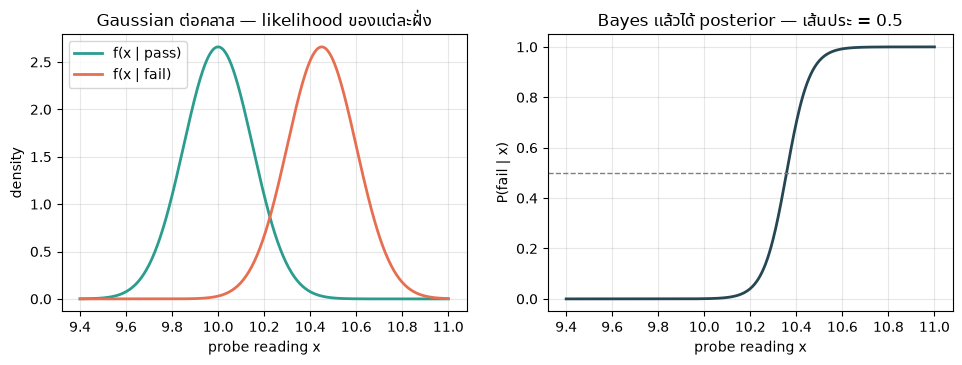

จุดที่ P(fail | x) = 0.5 อยู่ที่ x ≈ 10.358 — นี่คือ decision boundary แบบมีที่มา


In [6]:
mu_pass, sd_pass = 10.00, 0.15
mu_fail, sd_fail = 10.45, 0.15


def gauss_pdf(x, mu, sd):
    return np.exp(-0.5 * ((x - mu) / sd) ** 2) / (sd * np.sqrt(2 * np.pi))


xs = np.linspace(9.4, 11.0, 400)
like_pass = gauss_pdf(xs, mu_pass, sd_pass)  # f(x | pass)
like_fail = gauss_pdf(xs, mu_fail, sd_fail)  # f(x | fail)
post_fail = (
    like_fail * prev / (like_fail * prev + like_pass * (1 - prev))
)  # P(fail | x)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))
axes[0].plot(xs, like_pass, color="#2a9d8f", lw=2, label="f(x | pass)")
axes[0].plot(xs, like_fail, color="#e76f51", lw=2, label="f(x | fail)")
axes[0].set_xlabel("probe reading x")
axes[0].set_ylabel("density")
axes[0].set_title("Gaussian ต่อคลาส — likelihood ของแต่ละฝั่ง")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(xs, post_fail, color="#264653", lw=2)
axes[1].axhline(0.5, color="gray", ls="--", lw=1)
axes[1].set_xlabel("probe reading x")
axes[1].set_ylabel("P(fail | x)")
axes[1].set_title("Bayes แล้วได้ posterior — เส้นประ = 0.5")
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(alpha=0.3)
plt.show()

x_star = xs[np.argmin(np.abs(post_fail - 0.5))]
print(
    f"จุดที่ P(fail | x) = 0.5 อยู่ที่ x ≈ {
        x_star:.3f} — นี่คือ decision boundary แบบมีที่มา"
)


# ซ้าย: โมเดล "เข้าใจ" ว่าแต่ละคลาสอ่านค่ากระจายอย่างไร — ขวา: หารด้วยทั้งหมดแล้วคูณ prior กลับเข้าไป ก็ได้ **P(fail | x)** ที่วิ่งจาก 0 ไป 1 อย่างต่อเนื่อง
#
# นี่คือรูปทรงเดียวกับ logistic function ที่โมดูลหลักจะพบใน `predict_proba` — **โมเดล classification ไม่ได้ "ตัดสิน" โดยตรง มันประมาณความน่าจะเป็น แล้วเราเป็นคนตัดสินด้วย threshold**

# ## 7. จาก probability สู่ decision — threshold คือที่ที่เราเลือกเอง
#
# โมเดลให้ P(fail | measurement) ในช่วง [0, 1] แต่โรงงานต้องการคำตอบ 2 ทาง: ผ่าน / ไม่ผ่าน การตัดสินเกิดที่ **threshold t**:
#
# ```text
# P(fail | x) ≥ t  →  ตัดสินว่า FAIL
# P(fail | x) < t  →  ตัดสินว่า PASS
# ```
#
# ที่ t = 0.5 คือ "ไม่เอนไปทางไหนเลย" — แต่โรงงานมี **ต้นทุนต่างกัน** ต่อความผิดพลาดสองแบบ (ข้อถัดไป) เราจึงมีสิทธิ์เลือก t ไม่ใช่ 0.5 เสมอ

logistic function — ฟังก์ชันมาตรฐานที่ squish ค่าให้อยู่ใน [0, 1]


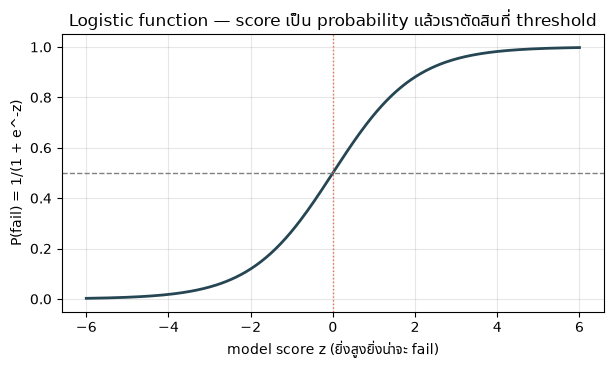

In [7]:
z = np.linspace(-6, 6, 300)
sig = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(z, sig, color="#264653", lw=2)
ax.axhline(0.5, color="gray", ls="--", lw=1)
ax.axvline(0, color="#e76f51", ls=":", lw=1)
ax.set_xlabel("model score z (ยิ่งสูงยิ่งน่าจะ fail)")
ax.set_ylabel("P(fail) = 1/(1 + e^-z)")
ax.set_title(
    "Logistic function — score เป็น probability แล้วเราตัดสินที่ threshold"
)
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.3)
plt.show()

# ## 8. ศัพท์เมโทรโลยี — false accept กับ false reject
#
# การตัดสิน pass/fail ผิดพลาดได้แค่สองทาง — และงานเมโทรโลยีมีชื่อเรียกที่ตรงกว่า "type I/II error":
#
# | | โมเดลตัดสิน PASS | โมเดลตัดสิน FAIL |
# |---|---|---|
# | **ของดีจริง (PASS)** | ถูกต้อง | **false reject** — ตัดของดีทิ้ง (producer's risk) |
# | **ของเสียจริง (FAIL)** | **false accept** — รับของเสียผ่าน (consumer's risk) | ถูกต้อง |
#
# - **false accept** = ของเสียหลุดไปถึงลูกค้า — แพงและเสียชื่อเสียง มักเป็นความเสี่ยงที่ต้องกดให้ต่ำสุด
# - **false reject** = ของดีถูกทิ้ง/ส่ง rework — สูญเปล่าแต่ "แค่" เงิน
#
# สองต้นทุนนี้แลกกันโดยตรงผ่าน threshold (ข้อ 7) — ไม่มีทางกดทั้งคู่พร้อมกันด้วยโมเดลเดิม ๆ นี่คือการตัดสินใจทางวิศวกรรม ไม่ใช่แค่การเลือกตัวเลขให้สวย

ประกอบทุกอย่างเข้าด้วยกัน: gauge จากข้อ 3 บนสายผลิต 10,000 ชิ้น


In [8]:
tp = int(round(sensitivity * n_fail))  # fail ที่จับได้ → ตัดสิน FAIL ถูก
fn = n_fail - tp  # fail ที่หลุด → **false accept**
fp = int(round(fpr * n_pass))  # pass ที่ถูกกล่าวหา → **false reject**
tn = n_pass - fp

print(
    f"สายผลิต {n_units:,} ชิ้น, base rate fail 6.6%, "
    f"gauge sensitivity 90%, false positive 5%"
)
print(f"\nถูกต้อง: จับของเสียได้ {tp:,} | ปล่อยของดีผ่าน {tn:,}")
print(
    f"false accept (รับของเสียผ่าน): {fn:,} ชิ้น  ← ของเสียทั้งหมด {n_fail:,} "
    f"ชิ้น หลุดไป {fn / n_fail * 100:.0f}%"
)
print(
    f"false reject (ตัดของดีทิ้ง)  : {fp:,} ชิ้น  ← ของดี {n_pass:,} ชิ้น "
    f"โดนตัดไป {fp / n_pass * 100:.1f}%"
)

สายผลิต 10,000 ชิ้น, base rate fail 6.6%, gauge sensitivity 90%, false positive 5%

ถูกต้อง: จับของเสียได้ 594 | ปล่อยของดีผ่าน 8,873
false accept (รับของเสียผ่าน): 66 ชิ้น  ← ของเสียทั้งหมด 660 ชิ้น หลุดไป 10%
false reject (ตัดของดีทิ้ง)  : 467 ชิ้น  ← ของดี 9,340 ชิ้น โดนตัดไป 5.0%


# ## สรุป
#
# - ความน่าจะเป็นมีสองมุมอ่าน (ความถี่ / ความเชื่อ) — classifier คือเครื่องประมาณ P(fail | measurement)
# - **Bayes** เชื่อม "gauge แม่นแค่ไหน" กับ "การเตือนน่าเชื่อแค่ไหน" — base rate 6.6% ทำให้ sensitivity 90% ให้ PPV เพียง ~56% (testing paradox)
# - ผล pass/fail ทีละชิ้นคือ **Bernoulli** เป็นล็อตคือ **Binomial** — ความเสี่ยงรวมทับเร็วกว่าที่คิด
# - สมมติฐาน **Gaussian ต่อ feature** + prior ให้ posterior P(fail | x) รูปทรงเดียวกับที่ `predict_proba` ส่งออก
# - **false accept** (รับของเสียผ่าน) กับ **false reject** (ตัดของดีทิ้ง) คือสองต้นทุนของ gauge — threshold คือปุ่มที่แลกสองต้นทุนนี้ โมดูลหลักจะเล่นกับปุ่มนี้ด้วยข้อมูลจริง